# Đề kiểm tra thực hành 2 - Solution

**Phân tích dữ liệu Bayesian - IUH**



In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from fractions import Fraction

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


## 2. Bài 1 - Từ sản phẩm lỗi quay ngược về xưởng sản xuất

**Đề bài.** Một công ty nhận sản phẩm từ ba xưởng $A,B,C$. Tỉ lệ sản lượng lần lượt là $40\%$, $35\%$, $25\%$. Tỉ lệ sản phẩm lỗi tại ba xưởng lần lượt là $2\%$, $3\%$, $5\%$.

- a) Tính xác suất một sản phẩm chọn ngẫu nhiên bị lỗi.
- b) Biết rằng sản phẩm bị lỗi, tính xác suất nó đến từ xưởng $C$.

### Ý nghĩa của bài tập

Đây là một bối cảnh Bayes rất tự nhiên: lỗi sản phẩm là dữ liệu quan sát được, còn xưởng sản xuất là nguyên nhân ẩn. Phần (a) dùng xác suất toàn phần để tính xác suất lỗi chung của cả công ty. Phần (b) là một posterior thực sự: sau khi thấy lỗi, ta cập nhật lại niềm tin về nơi sản phẩm đó được tạo ra.


### Công thức cốt lõi và cách đọc

Gọi $D$ là biến cố “sản phẩm bị lỗi”, còn $A,B,C$ là ba biến cố “sản phẩm đến từ xưởng tương ứng”.

Trước hết, xác suất lỗi chung được tính bằng quy tắc xác suất toàn phần:

$$
P(D)=P(D\mid A)P(A)+P(D\mid B)P(B)+P(D\mid C)P(C).
$$

Thay số:

$$
P(D)=0.02\cdot 0.40 + 0.03\cdot 0.35 + 0.05\cdot 0.25 = 0.031.
$$

Tiếp theo, posterior cần tìm là:

$$
P(C\mid D)=\frac{P(D\mid C)P(C)}{P(D)}
=\frac{0.05\cdot 0.25}{0.031} = \frac{25}{62} \approx 0.4032.
$$


In [37]:
source_prior = np.array([0.40, 0.35, 0.25])
defect_rates = np.array([0.02, 0.03, 0.05])

p_defect = np.dot(source_prior, defect_rates)
p_c_given_defect = source_prior[2] * defect_rates[2] / p_defect

print(f"Bai 1: P(defect) = {p_defect:.4f} = {100*p_defect:.2f}%")
print(f"Bai 1: P(C | defect) = {p_c_given_defect:.6f} = {100*p_c_given_defect:.2f}%")
print(f"Exact fraction for P(C | defect) = {Fraction(p_c_given_defect).limit_denominator()}")


Bai 1: P(defect) = 0.0310 = 3.10%
Bai 1: P(C | defect) = 0.403226 = 40.32%
Exact fraction for P(C | defect) = 25/62


### Interpretation

Kết quả cho thấy xác suất lỗi chung của công ty là $3.1\%$. Nhưng nếu đã biết sản phẩm bị lỗi, khả năng nó đến từ xưởng $C$ tăng lên khoảng $40.32\%$, lớn hơn prior ban đầu là $25\%$. Điều này hợp lý vì xưởng $C$ có tỉ lệ lỗi cao nhất trong ba xưởng.


## 3. Bài 2 - Posterior rời rạc cho số bi đỏ chưa biết

**Đề bài.** Một hộp có $8$ viên bi, gồm hai màu đỏ và xanh, nhưng chưa biết chính xác số bi đỏ. Gọi $A_k$ là biến cố “trong hộp có đúng $k$ viên bi đỏ”, với $k=0,1,\ldots,8$. Giả sử prior trên các $A_k$ là đều nhau. Người ta bốc không hoàn lại 3 viên và quan sát được dãy màu:

$$
R,\ R,\ B.
$$

Hãy viết posterior $P(A_k\mid R,R,B)$, tính các giá trị cho mọi $k$, xác định giá trị hậu nghiệm lớn nhất, và vẽ biểu đồ cột.

### Ý nghĩa của bài tập

Đây là một bài Bayesian rất đẹp vì tham số chưa biết không còn là một đại lượng liên tục mà là một tập hữu hạn các khả năng. Ta không cần tích phân; posterior chỉ là quá trình gán lại trọng số cho từng khả năng $k$ sau khi nhìn dữ liệu. Nhờ vậy, người học thấy rất rõ câu “posterior tỉ lệ với likelihood nhân prior” hoạt động như thế nào trên từng giả thuyết rời rạc.


### Công thức cốt lõi và cách đọc

Ta đi chậm theo đúng tinh thần Bayes: **prior -> likelihood -> posterior**.

**Bước 1. Prior trên các giả thuyết.** Vì đề cho prior đều, nên:

$$
P(A_k)=\frac{1}{9}, \qquad k=0,1,\ldots,8.
$$

Điều này có nghĩa là trước khi nhìn dữ liệu, ta chưa ưu tiên hộp có $k$ viên đỏ nào hơn hộp khác.

**Bước 2. Likelihood dưới từng giả thuyết $A_k$.** Nếu trong hộp có đúng $k$ viên đỏ, thì sẽ có $8-k$ viên xanh. Để quan sát được dãy $R,R,B$ khi bốc **không hoàn lại**, ta phải đi qua ba bước liên tiếp:

- Lượt 1 đỏ: xác suất $\frac{k}{8}$.
- Lượt 2 đỏ tiếp: lúc này còn $k-1$ viên đỏ trên tổng $7$ viên, nên xác suất là $\frac{k-1}{7}$.
- Lượt 3 xanh: sau hai lượt đầu, số viên xanh vẫn là $8-k$ trên tổng $6$ viên còn lại, nên xác suất là $\frac{8-k}{6}$.

Vì vậy:

$$
P(R,R,B\mid A_k)=\frac{k}{8}\cdot\frac{k-1}{7}\cdot\frac{8-k}{6}.
$$

**Bước 3. Cập nhật Bayes.** Theo công thức Bayes:

$$
P(A_k\mid R,R,B) \propto P(R,R,B\mid A_k)P(A_k).
$$

Do prior là đều, mọi $A_k$ đều cùng nhân với $\frac{1}{9}$, nên posterior chỉ khác nhau ở phần likelihood:

$$
P(A_k\mid R,R,B) \propto k(k-1)(8-k).
$$

**Vì sao ở đây không viết ngay mẫu số $P(R,R,B)$?** Công thức Bayes đầy đủ là:

$$
P(A_k\mid R,R,B)=\frac{P(R,R,B\mid A_k)P(A_k)}{P(R,R,B)}.
$$

Nhưng khi ta đang **so sánh các giả thuyết theo $k$**, thì $P(R,R,B)$ là cùng một hằng số cho mọi $k$. Vì vậy ta tạm gộp nó vào hằng số chuẩn hóa và viết ngắn gọn bằng dấu $\propto$.

Đến bước cuối, ta chuẩn hóa lại bằng cách chia cho tổng các trọng số chưa chuẩn hóa:

$$
P(R,R,B)=\sum_{j=0}^8 P(R,R,B\mid A_j)P(A_j).
$$

Trong code, đại lượng này chính là `normalizing_constant`. Nói cách khác, công thức Bayes **vẫn có chia cho $P(R,R,B)$**, chỉ là ta dời bước chia đó xuống cuối để việc tính toán và so sánh dễ nhìn hơn.

Nhìn công thức này ta thấy ngay:

- $k=0$ hoặc $k=1$: không thể có hai viên đỏ đầu tiên.
- $k=8$: không thể có viên xanh ở lượt thứ ba.

Nên các trường hợp đó phải có posterior bằng $0$.

**Bước 4. So vài giá trị cụ thể để bớt trừu tượng.** Bỏ qua hằng số chuẩn hóa, ta chỉ cần so các trọng số:

- $k=4$: trọng số tỉ lệ với $4\cdot3\cdot4=48$.
- $k=5$: trọng số tỉ lệ với $5\cdot4\cdot3=60$.
- $k=6$: trọng số tỉ lệ với $6\cdot5\cdot2=60$.
- $k=7$: trọng số tỉ lệ với $7\cdot6\cdot1=42$.

Vì vậy việc $k=5$ và $k=6$ cùng có posterior lớn nhất là điều rất tự nhiên, chứ không phải kết quả “bất ngờ” do máy tính tạo ra.


Bai 2: likelihood for each k
  k = 0: 0.000000
  k = 1: 0.000000
  k = 2: 0.035714
  k = 3: 0.089286
  k = 4: 0.142857
  k = 5: 0.178571
  k = 6: 0.178571
  k = 7: 0.125000
  k = 8: 0.000000

Bai 2: unnormalized posterior weights
  k = 0: 0.000000
  k = 1: 0.000000
  k = 2: 0.003968
  k = 3: 0.009921
  k = 4: 0.015873
  k = 5: 0.019841
  k = 6: 0.019841
  k = 7: 0.013889
  k = 8: 0.000000

Bai 2: normalizing constant = 0.083333

Bai 2: posterior for each k
  k = 0: 0.000000 = 0
  k = 1: 0.000000 = 0
  k = 2: 0.047619 = 1/21
  k = 3: 0.119048 = 5/42
  k = 4: 0.190476 = 4/21
  k = 5: 0.238095 = 5/21
  k = 6: 0.238095 = 5/21
  k = 7: 0.166667 = 1/6
  k = 8: 0.000000 = 0

Bai 2: posterior largest at k = [5, 6] with value 0.238095


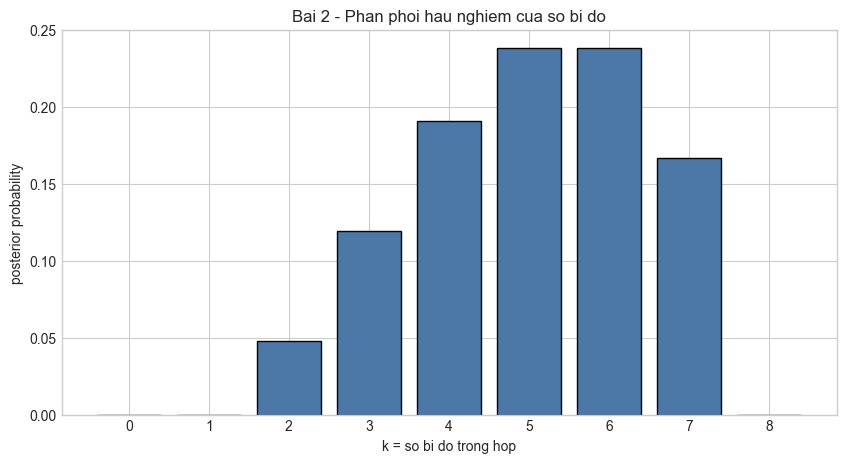

In [38]:
# Ta tính likelihood, trọng số hậu nghiệm chưa chuẩn hóa, rồi mới chuẩn hóa thành posterior.
k_values = np.arange(9)
prior_k = np.ones(9) / 9

likelihood = np.zeros(9)
for k in k_values:
    if 2 <= k <= 7:
        likelihood[k] = (k / 8) * ((k - 1) / 7) * ((8 - k) / 6)

posterior_unnorm = prior_k * likelihood
normalizing_constant = posterior_unnorm.sum()
posterior = posterior_unnorm / normalizing_constant

print("Bai 2: likelihood for each k")
for k, val in zip(k_values, likelihood):
    print(f"  k = {k}: {val:.6f}")

print()
print("Bai 2: unnormalized posterior weights")
for k, val in zip(k_values, posterior_unnorm):
    print(f"  k = {k}: {val:.6f}")

print()
print(f"Bai 2: normalizing constant = {normalizing_constant:.6f}")

print()
print("Bai 2: posterior for each k")
for k, val in zip(k_values, posterior):
    frac = Fraction(val).limit_denominator()
    print(f"  k = {k}: {val:.6f} = {frac}")

max_posterior = posterior.max()
map_k_values = k_values[np.isclose(posterior, max_posterior)]
print()
print(f"Bai 2: posterior largest at k = {map_k_values.tolist()} with value {max_posterior:.6f}")

plt.bar(k_values, posterior, color='#4C78A8', edgecolor='black')
plt.xticks(k_values)
plt.title('Bai 2 - Phan phoi hau nghiem cua so bi do')
plt.xlabel('k = so bi do trong hop')
plt.ylabel('posterior probability')
plt.show()


### Interpretation

Posterior lớn nhất xuất hiện tại $k=5$ và $k=6$ với cùng xác suất hậu nghiệm. Cách đọc trực giác là như sau:

- Nếu $k$ quá nhỏ thì rất khó, thậm chí không thể, quan sát được hai viên đỏ đầu tiên.
- Nếu $k$ quá lớn, đặc biệt là $k=8$, thì lại không còn chỗ cho viên xanh ở lượt thứ ba.
- Vì prior là đều, hình dạng của posterior ở bài này gần như được quyết định hoàn toàn bởi likelihood.

Do đó các giá trị trung gian nhưng vẫn thiên về nhiều đỏ, cụ thể là $k=5$ và $k=6$, trở thành những giả thuyết hợp lý nhất sau khi nhìn dữ liệu $R,R,B$.

Bài này rất đáng học vì nó cho thấy Bayes không nhất thiết lúc nào cũng làm việc với một tham số liên tục và một đường cong mật độ. Ở đây posterior chỉ là một **phân phối xác suất trên 9 khả năng rời rạc**, và việc cập nhật thực chất là gán lại trọng số cho từng khả năng đó.


## 4. Bài 3 - Liên hợp Beta-Geometric trong thí nghiệm y học

**Đề bài.** Trong một **thí nghiệm y học**, các bệnh nhân được đưa vào thử nghiệm tuần tự cho đến khi xuất hiện bệnh nhân đầu tiên có phản ứng tốt với thuốc. Gọi $p$ là xác suất một bệnh nhân bất kỳ đáp ứng tốt với thuốc. Trước khi quan sát dữ liệu, giả sử:

$$
p \sim \mathrm{Beta}(3,2).
$$

Gọi $Y$ là số bệnh nhân cần theo dõi cho đến khi xuất hiện **ca đáp ứng tốt đầu tiên**, và giả sử

$$
Y\mid p \sim \mathrm{Geometric}(p).
$$

Quan sát được $Y=4$.

**Gợi ý.** Với quy ước Geometric đang dùng,
$$
P(Y=y\mid p)=(1-p)^{y-1}p, \qquad y=1,2,\ldots
$$
và posterior thỏa
$$
p(p\mid y) \propto p(y\mid p)\,p(p).
$$

- a) Xác định phân phối hậu nghiệm của $p$.
- b) Tính kỳ vọng hậu nghiệm của $p$ và vẽ prior, posterior trên cùng hệ trục.

### Ý nghĩa của bài tập

Bài này vẫn là một bài liên hợp, nhưng câu chuyện dữ liệu giờ mang màu sắc của một thí nghiệm y học thực sự. Ta không đếm số ca đáp ứng trong một cỡ mẫu cố định, mà quan sát **phải theo dõi đến bệnh nhân thứ mấy mới thấy ca đáp ứng tốt đầu tiên**. Điều đó dẫn ta đến mô hình Geometric với prior Beta. Nhờ vậy, bài vẫn giữ tinh thần conjugacy, nhưng khác rõ với bài Gaussian ở thực hành 1 và cũng không trùng với bài đếm Gamma-Poisson ở Bài 4.


### Công thức cốt lõi và cách đọc

Nếu prior là

$$
p \sim \mathrm{Beta}(\alpha,\beta),
$$

và dữ liệu có dạng

$$
Y\mid p \sim \mathrm{Geometric}(p), \qquad P(Y=y\mid p)=(1-p)^{y-1}p, \quad y=1,2,\ldots
$$

thì khi quan sát được $Y=y$, posterior là

$$
p\mid y \sim \mathrm{Beta}(\alpha+1,\beta+y-1).
$$

Trong bài này:

- $\alpha = 3$,
- $\beta = 2$,
- $y = 4$.

Do đó:

$$
p\mid y \sim \mathrm{Beta}(4,5).
$$

Kỳ vọng hậu nghiệm là:

$$
E[p\mid y]=\frac{4}{4+5}=\frac{4}{9}\approx 0.4444.
$$

Cách đọc trực giác là: dữ liệu $Y=4$ tương ứng với ba bệnh nhân đầu **không đáp ứng tốt** và bệnh nhân thứ tư mới **đáp ứng tốt**. Vì vậy likelihood đóng góp đúng một lần thành công và ba lần thất bại vào phép cập nhật.


Bai 3: posterior = Beta(4, 5)
Bai 3: posterior mean = 0.444444


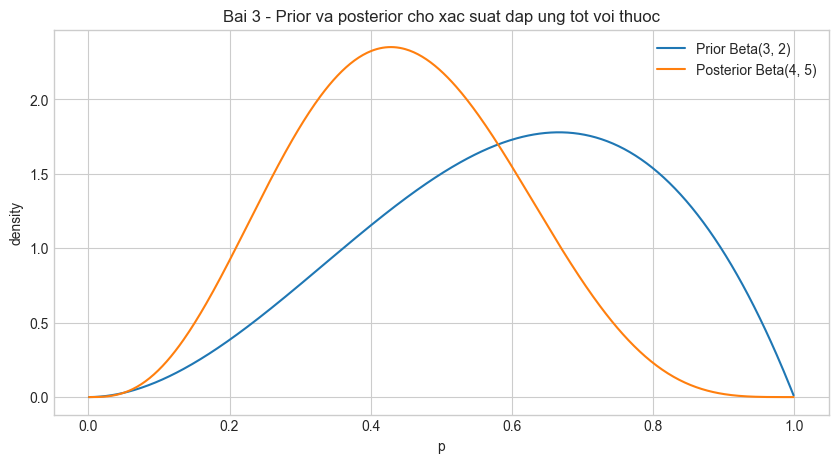

In [39]:
alpha_prior_bai3 = 3
beta_prior_bai3 = 2
y_first_success = 4

alpha_post_bai3 = alpha_prior_bai3 + 1
beta_post_bai3 = beta_prior_bai3 + y_first_success - 1
posterior_mean_bai3 = alpha_post_bai3 / (alpha_post_bai3 + beta_post_bai3)

print(f"Bai 3: posterior = Beta({alpha_post_bai3}, {beta_post_bai3})")
print(f"Bai 3: posterior mean = {posterior_mean_bai3:.6f}")

x_grid = np.linspace(0.001, 0.999, 500)
prior_pdf_bai3 = stats.beta.pdf(x_grid, alpha_prior_bai3, beta_prior_bai3)
posterior_pdf_bai3 = stats.beta.pdf(x_grid, alpha_post_bai3, beta_post_bai3)

plt.plot(x_grid, prior_pdf_bai3, label=f'Prior Beta({alpha_prior_bai3}, {beta_prior_bai3})')
plt.plot(x_grid, posterior_pdf_bai3, label=f'Posterior Beta({alpha_post_bai3}, {beta_post_bai3})')
plt.title('Bai 3 - Prior va posterior cho xac suat dap ung tot voi thuoc')
plt.xlabel('p')
plt.ylabel('density')
plt.legend()
plt.show()


### Interpretation

Posterior thu được là

$$
p\mid y \sim \mathrm{Beta}(4,5),
$$

với kỳ vọng hậu nghiệm xấp xỉ $0.4444$. Vì phải đến bệnh nhân thứ 4 mới xuất hiện ca đáp ứng tốt đầu tiên, dữ liệu đã kéo posterior về phía các giá trị $p$ thấp hơn so với prior ban đầu. Điều này hợp trực giác y học: nếu thuốc chưa cho thấy phản ứng tốt sớm ở những bệnh nhân đầu, ta sẽ bớt tin rằng xác suất đáp ứng của mỗi bệnh nhân là cao.


## 5. Bài 4 - Liên hợp Gamma-Poisson trong bối cảnh kinh tế

**Đề bài.** Gọi $a,b$ là hai chữ số cuối của MSSV. Trong một bối cảnh **kinh tế**, giả sử số doanh nghiệp nhỏ **giải thể mới** trong mỗi tháng tại một quận có phân phối Poisson với tham số $\lambda$. Trước khi quan sát dữ liệu mới, giả sử $\lambda$ có phân phối Gamma với kỳ vọng $3$ và độ lệch chuẩn $1$. Trong 3 tháng gần đây, số doanh nghiệp nhỏ giải thể mới lần lượt là $a,b,2$.

- a) Xác định phân phối hậu nghiệm của $\lambda$.
- b) Tính kỳ vọng hậu nghiệm của $\lambda$ và vẽ mật độ prior, posterior trên cùng hệ trục.


### Công thức cốt lõi và cách đọc

Ta dùng tham số hóa Gamma theo **shape-rate**:

$$
\lambda \sim \mathrm{Gamma}(\alpha,\beta),
$$

với

$$
E[\lambda]=\frac{\alpha}{\beta},
\qquad
\mathrm{Var}(\lambda)=\frac{\alpha}{\beta^2},
\qquad
\mathrm{sd}(\lambda)=\frac{\sqrt{\alpha}}{\beta}.
$$

Từ prior có kỳ vọng $3$ và độ lệch chuẩn $1$, ta giải được:

$$
\frac{\alpha_0}{\beta_0}=3,
\qquad
\frac{\sqrt{\alpha_0}}{\beta_0}=1
\quad \Longrightarrow \quad
\alpha_0=9,\ \beta_0=3.
$$

Với dữ liệu đếm độc lập

$$
Y_i\mid \lambda \sim \mathrm{Poisson}(\lambda),
$$

nếu quan sát $y_1,\ldots,y_n$, thì posterior là:

$$
\lambda\mid y \sim \mathrm{Gamma}\left(\alpha_0+\sum_{i=1}^{n} y_i,\ \beta_0+n\right).
$$

Với MSSV hiện tại, ta dùng ba quan sát $a,b,2$, được hiểu là số doanh nghiệp nhỏ giải thể mới trong ba tháng liên tiếp.


Bai 4: du lieu so doanh nghiep giai the moi = [7, 1, 2]
Bai 4: prior = Gamma(shape=9, rate=3)
Bai 4: posterior = Gamma(shape=19, rate=6)
Bai 4: posterior mean = 3.166667


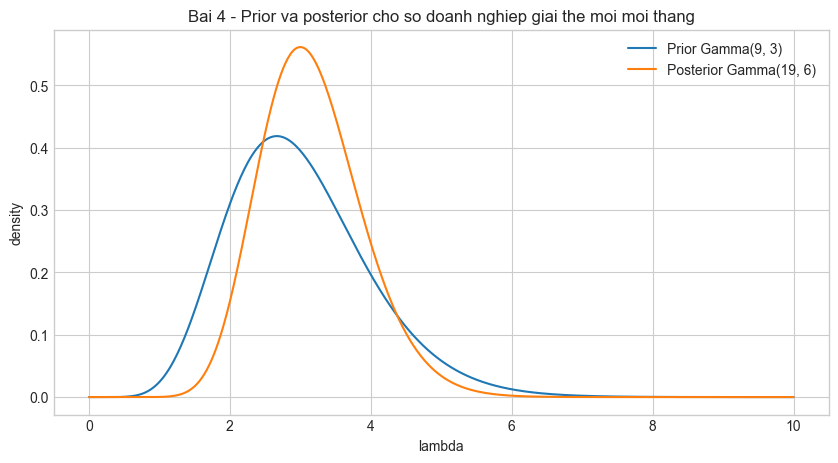

In [40]:
a_bai4 = second_last_digit
b_bai4 = last_digit
firm_exit_counts = np.array([a_bai4, b_bai4, 2])

prior_mean = 3.0
prior_sd = 1.0
alpha0 = prior_mean**2 / prior_sd**2
beta0 = prior_mean / prior_sd**2

posterior_alpha_bai4 = alpha0 + firm_exit_counts.sum()
posterior_beta_bai4 = beta0 + len(firm_exit_counts)
posterior_mean_bai4 = posterior_alpha_bai4 / posterior_beta_bai4

print(f"Bai 4: du lieu so doanh nghiep giai the moi = {firm_exit_counts.tolist()}")
print(f"Bai 4: prior = Gamma(shape={alpha0:.0f}, rate={beta0:.0f})")
print(f"Bai 4: posterior = Gamma(shape={posterior_alpha_bai4:.0f}, rate={posterior_beta_bai4:.0f})")
print(f"Bai 4: posterior mean = {posterior_mean_bai4:.6f}")

grid_bai4 = np.linspace(0.001, 10, 600)
prior_pdf_bai4 = stats.gamma.pdf(grid_bai4, a=alpha0, scale=1 / beta0)
posterior_pdf_bai4 = stats.gamma.pdf(grid_bai4, a=posterior_alpha_bai4, scale=1 / posterior_beta_bai4)

plt.plot(grid_bai4, prior_pdf_bai4, label=f'Prior Gamma({alpha0:.0f}, {beta0:.0f})')
plt.plot(grid_bai4, posterior_pdf_bai4, label=f'Posterior Gamma({posterior_alpha_bai4:.0f}, {posterior_beta_bai4:.0f})')
plt.title('Bai 4 - Prior va posterior cho so doanh nghiep giai the moi moi thang')
plt.xlabel('lambda')
plt.ylabel('density')
plt.legend()
plt.show()


### Interpretation

Với MSSV minh họa `20123671`, ta có dữ liệu quan sát là số doanh nghiệp nhỏ giải thể mới theo ba tháng: $(7,1,2)$, nên:

$$
\lambda\mid y \sim \mathrm{Gamma}(19,6).
$$

Do đó kỳ vọng hậu nghiệm là:

$$
E[\lambda\mid y]=\frac{19}{6}\approx 3.1667.
$$

So với prior mean bằng $3$, posterior mean tăng nhẹ vì tổng số doanh nghiệp nhỏ giải thể mới quan sát được trong 3 tháng là $10$, hơi cao hơn mức trung bình mà prior ngầm kỳ vọng. Đồ thị cũng cho thấy posterior tập trung hơn prior, tức là sau dữ liệu mới, độ bất định về $\lambda$ đã giảm xuống.


In [41]:
print('Tom tat nhanh voi MSSV hien tai')
print('-' * 50)
print(f"MSSV: {student_id}")
print(f"Bai 1: P(defect) = {100*p_defect:.2f}%,   P(C | defect) = {100*p_c_given_defect:.2f}%")
print(f"Bai 2: MAP k values = {map_k_values.tolist()}, posterior max = {max_posterior:.6f}")
print(f"Bai 3: posterior = Beta({alpha_post_bai3}, {beta_post_bai3}), mean = {posterior_mean_bai3:.6f}")
print(f"Bai 4: posterior = Gamma({posterior_alpha_bai4:.0f}, {posterior_beta_bai4:.0f}), mean = {posterior_mean_bai4:.6f}")


Tom tat nhanh voi MSSV hien tai
--------------------------------------------------
MSSV: 20123671
Bai 1: P(defect) = 3.10%,   P(C | defect) = 40.32%
Bai 2: MAP k values = [5, 6], posterior max = 0.238095
Bai 3: posterior = Beta(4, 5), mean = 0.444444
Bai 4: posterior = Gamma(19, 6), mean = 3.166667
